In [171]:
import cuml
print(cuml.__version__)

25.10.00


In [172]:
# %load_ext cuml.accel
import pandas as pd
import numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [173]:
df = pd.read_csv("./data/train.csv")

In [174]:
df[df["Cabin"] == "C85"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [175]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [176]:
# Just Id automatically generated, can drop
df.drop(columns="PassengerId", inplace=True)

In [177]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [178]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

## EDA

[Text(0, 0, '549'), Text(0, 0, '342')]

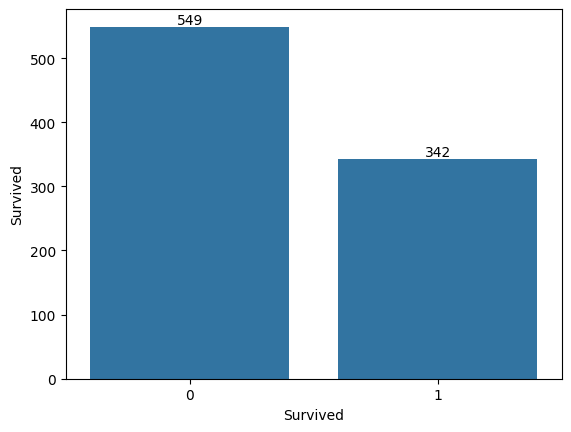

In [180]:
ax = sns.barplot(df, x="Survived", y="Survived", estimator="count", errorbar=None)
ax.bar_label(ax.containers[0], fontsize =10)

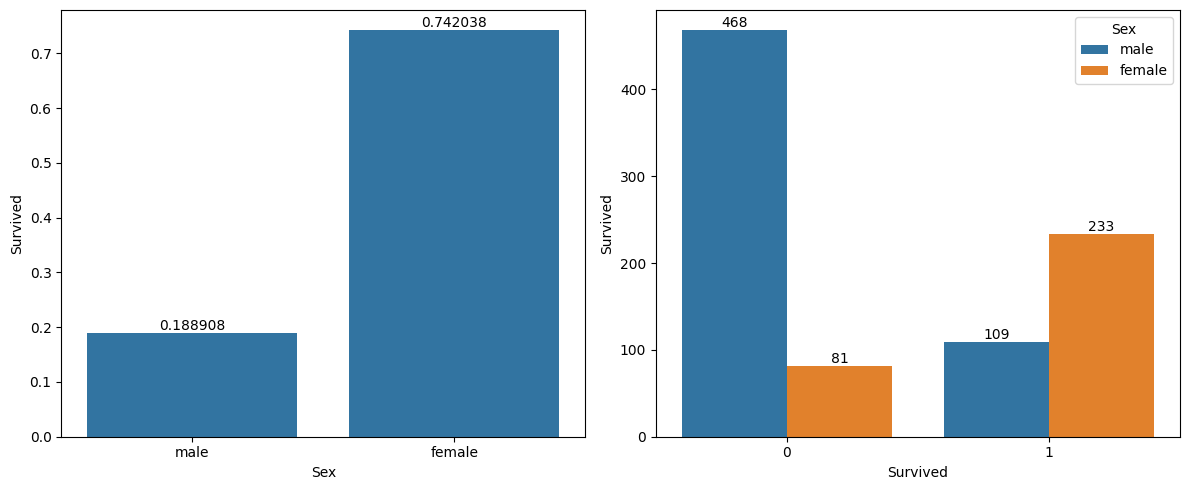

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First plot
sns.barplot(df, x="Sex", y="Survived", errorbar=None, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=10)

# Second plot
sns.barplot(df, x="Survived", y="Survived", hue="Sex", estimator="count", errorbar=None, ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

plt.tight_layout()

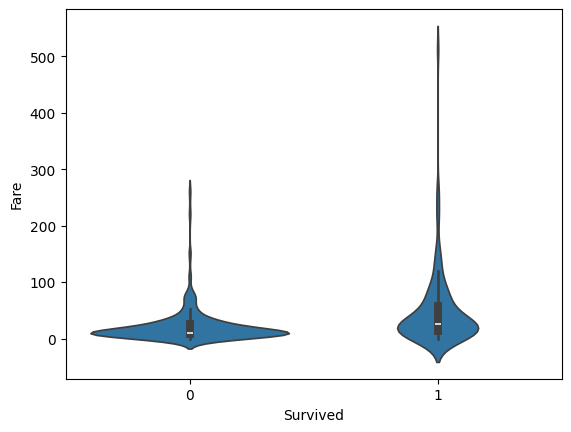

In [182]:
ax = sns.violinplot(df[df["Fare"] < 600], x="Survived", y="Fare")

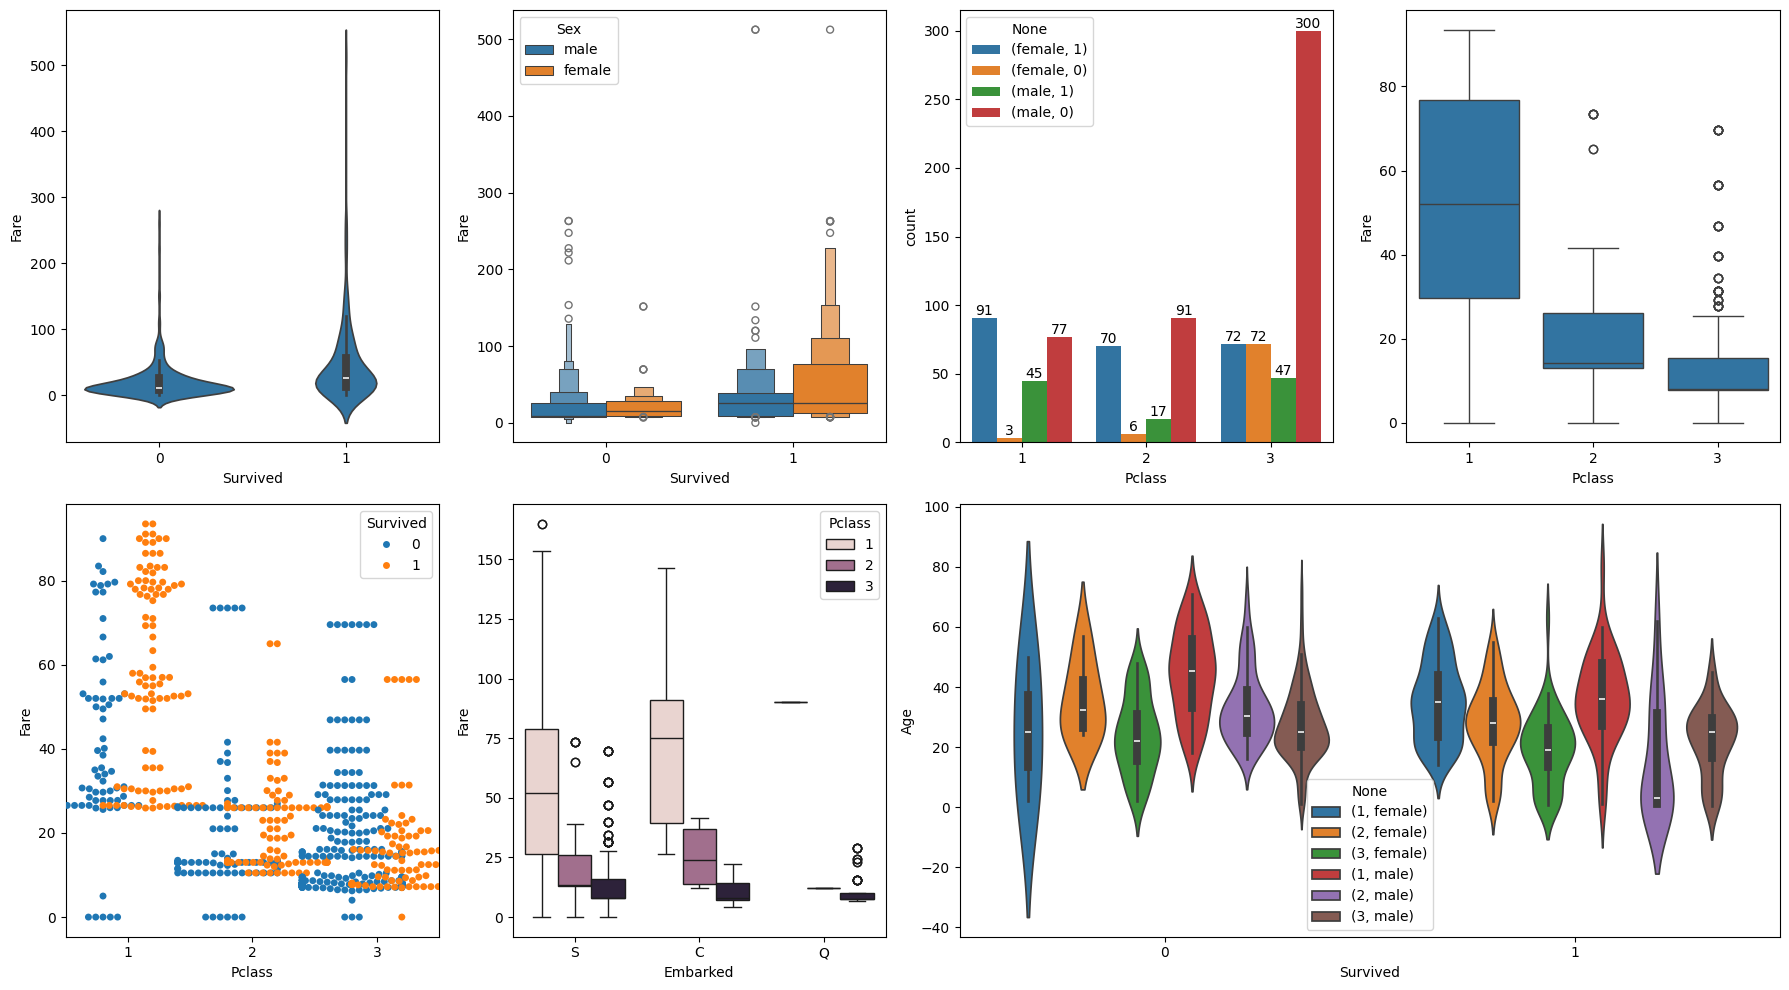

In [183]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig)

# Regular single-cell plots
axes_0_0 = fig.add_subplot(gs[0, 0])
axes_0_1 = fig.add_subplot(gs[0, 1])
axes_0_2 = fig.add_subplot(gs[0, 2])
axes_0_3 = fig.add_subplot(gs[0, 3])
axes_1_0 = fig.add_subplot(gs[1, 0])
axes_1_1 = fig.add_subplot(gs[1, 1])

# Span 2 columns (columns 2 and 3)
axes_1_2 = fig.add_subplot(gs[1, 2:4])  # This spans columns 2 and 3

df_fare = df[df["Fare"] < 1000]

sns.violinplot(df_fare, x="Survived", y="Fare", ax=axes_0_0)
sns.boxenplot(df_fare, x="Survived", y="Fare", hue="Sex", ax=axes_0_1)

hue = df[["Sex", "Survived"]].apply(lambda row: f"({row.Sex}, {row.Survived})", axis=1)
hue_order = ["(female, 1)", "(female, 0)", "(male, 1)", "(male, 0)"]
sns.countplot(df, x="Pclass", hue=hue, hue_order=hue_order, ax=axes_0_2)
for container in axes_0_2.containers:
    axes_0_2.bar_label(container, fontsize=10)

sns.boxplot(df[df["Fare"] < 100], x="Pclass", y="Fare", ax=axes_0_3)
sns.swarmplot(df[df["Fare"] < 100], x="Pclass", y="Fare", hue="Survived", dodge=True, ax=axes_1_0, warn_thresh=100)
sns.boxplot(df[df["Fare"] < 200], y="Fare", x="Embarked", hue="Pclass", ax=axes_1_1)

# Wide violin plot spanning 2 columns
hue = df[["Pclass", "Sex"]].apply(lambda row: f"({row.Pclass}, {row.Sex})", axis=1)
hue_order = ["(1, female)", "(2, female)", "(3, female)", "(1, male)", "(2, male)", "(3, male)"]
sns.violinplot(df, y="Age", x="Survived", hue=hue, ax=axes_1_2, legend="auto", hue_order=hue_order)

plt.tight_layout()


# The Pclass mean show that most of the woman in class 3 die while the survivor has a mean of 2
# The std also show that small deviation in the death, showing most death belong to a single class
# Most rich female in first and second class do not die
# Some rich male live although not by much 
# Female in third class is just a toss up 

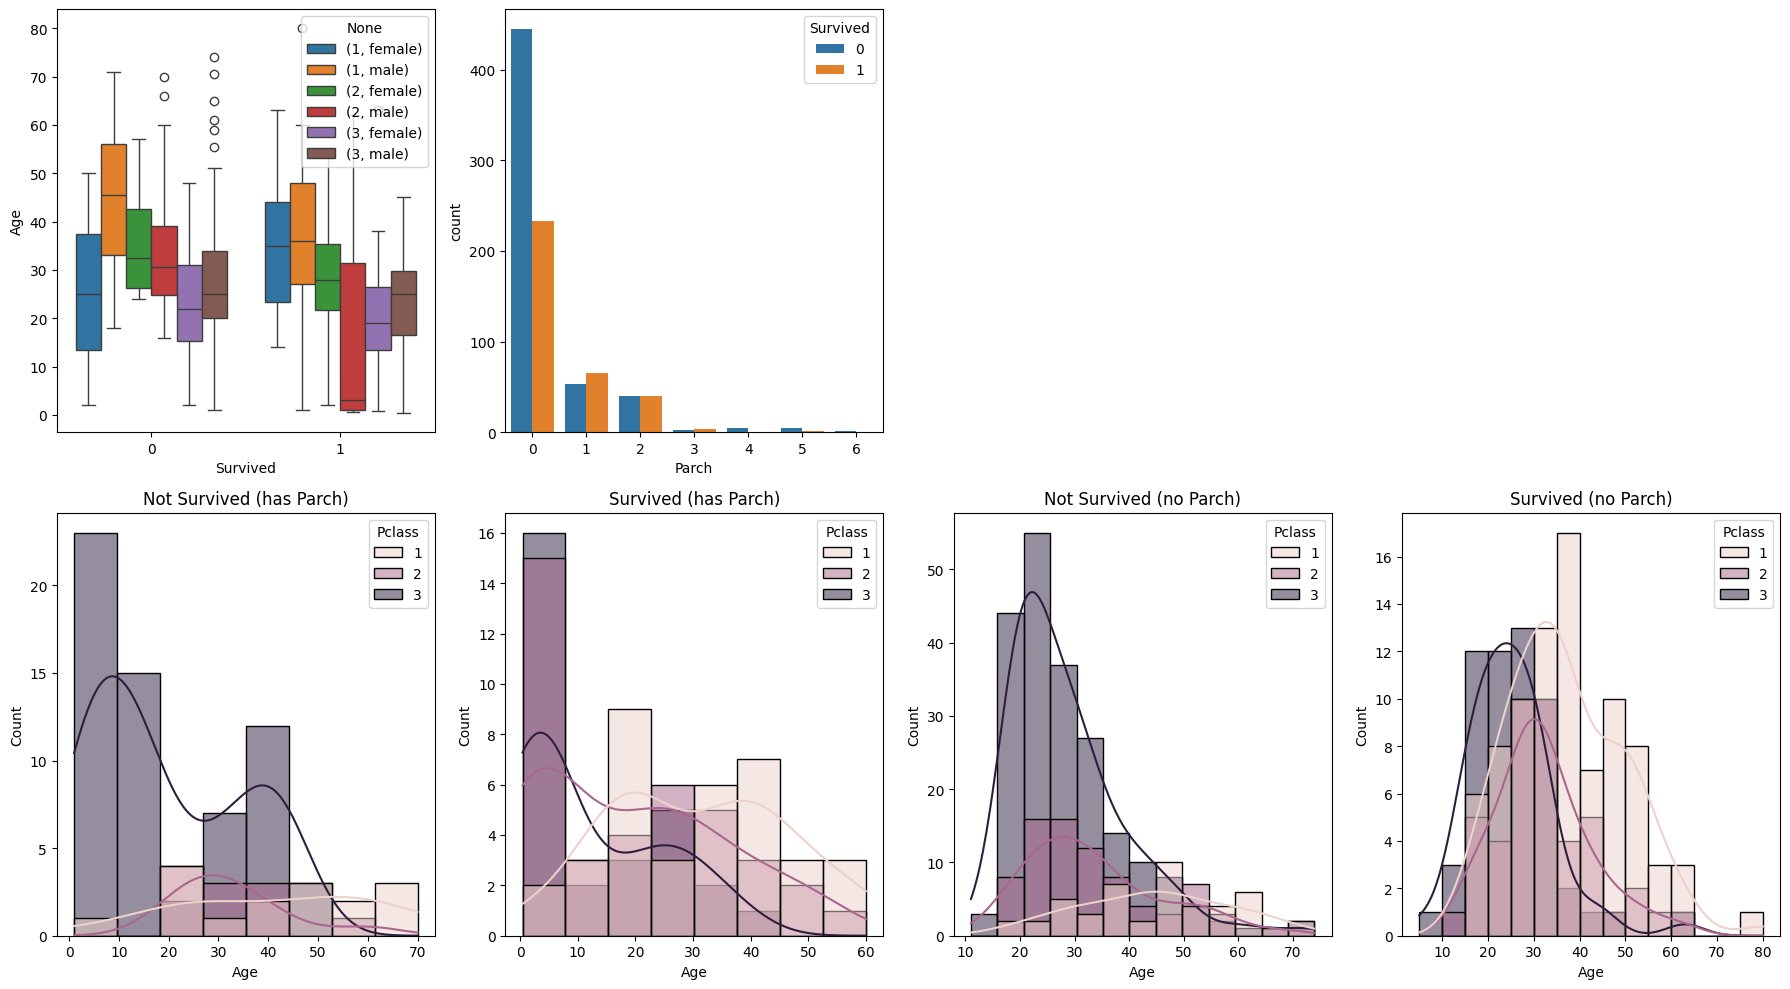

In [184]:
fig = plt.figure(figsize=(18,10))
gs = gridspec.GridSpec(2, 4, figure=fig)

axes_0_0 = fig.add_subplot(gs[0, 0])
axes_0_1 = fig.add_subplot(gs[0, 1])
axes_1_0 = fig.add_subplot(gs[1, 0])  # Survived = 0, hasParch = True
axes_1_1 = fig.add_subplot(gs[1, 1])  # Survived = 1, hasParch = True
axes_1_2 = fig.add_subplot(gs[1, 2])  # Survived = 0, hasParch = False
axes_1_3 = fig.add_subplot(gs[1, 3])  # Survived = 1, hasParch = False

hue = "(" + df["Pclass"].astype(str) + ", " + df["Sex"] + ")"
hue_order = ["(1, female)", "(1, male)", "(2, female)", "(2, male)", "(3, female)", "(3, male)"]
ax = sns.boxplot(df, x="Survived", y="Age", hue=hue, hue_order=hue_order, ax=axes_0_0)

sns.countplot(df, x="Parch", hue="Survived", ax=axes_0_1)

df_hasParch = df.copy()
df_hasParch["hasParch"] = df["Parch"] > 0

# Plot for not survived, has Parch
subset = df_hasParch[(df_hasParch["Survived"] == 0) & (df_hasParch["hasParch"] == True)]
sns.histplot(subset, x="Age", hue="Pclass", kde=True, ax=axes_1_0)
axes_1_0.set_title("Not Survived (has Parch)")

# Plot for survived, has Parch
subset = df_hasParch[(df_hasParch["Survived"] == 1) & (df_hasParch["hasParch"] == True)]
sns.histplot(subset, x="Age", hue="Pclass", kde=True, ax=axes_1_1)
axes_1_1.set_title("Survived (has Parch)")

# Plot for not survived, no Parch
subset = df_hasParch[(df_hasParch["Survived"] == 0) & (df_hasParch["hasParch"] == False)]
sns.histplot(subset, x="Age", hue="Pclass", kde=True, ax=axes_1_2)
axes_1_2.set_title("Not Survived (no Parch)")

# Plot for survived, no Parch
subset = df_hasParch[(df_hasParch["Survived"] == 1) & (df_hasParch["hasParch"] == False)]
sns.histplot(subset, x="Age", hue="Pclass", kde=True, ax=axes_1_3)
axes_1_3.set_title("Survived (no Parch)")
# Survived people generally on the older side

plt.tight_layout()

In [185]:
df_hasParch[df_hasParch["hasParch"] == True]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hasParch
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,True
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,True
10,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,True
13,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S,True
16,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q,True
...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,True
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,True
880,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,True
885,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,True


In [186]:
df.groupby(["Embarked", "Pclass", "Sex"])[["Survived"]].agg(["count", "mean", "std"])
# why the hell is people from queen town and cherboug also has a higher chance of survial in class 3
# Female, except will generally has a higher suvival rate, except for in southampton

Survived                    
                          count      mean       std
Embarked Pclass Sex                                
C        1      female       43  0.976744  0.152499
                male         42  0.404762  0.496796
         2      female        7  1.000000  0.000000
                male         10  0.200000  0.421637
         3      female       23  0.652174  0.486985
                male         43  0.232558  0.427463
Q        1      female        1  1.000000       NaN
                male          1  0.000000       NaN
         2      female        2  1.000000  0.000000
                male          1  0.000000       NaN
         3      female       33  0.727273  0.452267
                male         39  0.076923  0.269953
S        1      female       48  0.958333  0.201941
                male         79  0.354430  0.481397
         2      female       67  0.910448  0.287694
                male         97  0.154639  0.363439
         3      female       88  0.375000  0.486897
                male        265  0.128302  0.335058

In [187]:
df.groupby(["Embarked", "Pclass", "Sex"])[["Survived"]].agg("mean")

Survived
Embarked Pclass Sex             
C        1      female  0.976744
                male    0.404762
         2      female  1.000000
                male    0.200000
         3      female  0.652174
                male    0.232558
Q        1      female  1.000000
                male    0.000000
         2      female  1.000000
                male    0.000000
         3      female  0.727273
                male    0.076923
S        1      female  0.958333
                male    0.354430
         2      female  0.910448
                male    0.154639
         3      female  0.375000
                male    0.128302

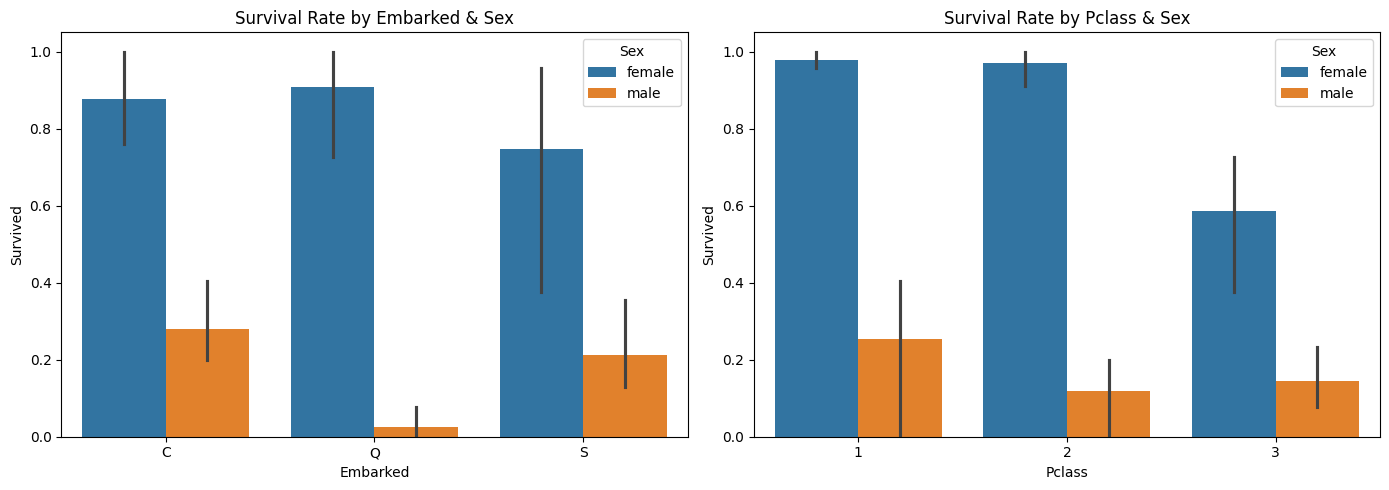

In [188]:
# Get mean survival rate by groups
survival_by_group = df.groupby(["Embarked", "Pclass", "Sex"])[["Survived"]].mean().reset_index()

# Boxplot by Embarked, with hue for Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=survival_by_group, x="Embarked", y="Survived", hue="Sex", ax=axes[0])
axes[0].set_title("Survival Rate by Embarked & Sex")

sns.barplot(data=survival_by_group, x="Pclass", y="Survived", hue="Sex", ax=axes[1])
axes[1].set_title("Survival Rate by Pclass & Sex")

plt.tight_layout()

In [189]:
hue = df.groupby(["Embarked", "Pclass", "Sex"])

# sns.boxplot(df, x="")

In [190]:
df.groupby(["Survived", "Pclass", "Sex"])[["Age"]].agg(["count", "mean", "std"])
# People who die tend to be older 

Age                      
                       count       mean        std
Survived Pclass Sex                               
0        1      female     3  25.666667  24.006943
                male      61  44.581967  14.457749
         2      female     6  36.000000  12.915107
                male      84  33.369048  12.158125
         3      female    55  23.818182  12.833465
                male     215  27.255814  12.135707
1        1      female    82  34.939024  13.223014
                male      40  36.248000  14.936744
         2      female    68  28.080882  12.764693
                male      15  16.022000  19.547122
         3      female    47  19.329787  12.303246
                male      38  22.274211  11.555786

In [191]:
df[(df["Fare"] > 20) & (df["Pclass"] == 3)][["Survived", "Fare", "Pclass", "Age", "Embarked"]]

,Survived,Fare,Pclass,Age,Embarked
7,0,21.0750,3,2.0,S
13,0,31.2750,3,39.0,S
16,0,29.1250,3,2.0,Q
24,0,21.0750,3,8.0,S
25,1,31.3875,3,38.0,S
...,...,...,...,...,...
846,0,69.5500,3,NaN,S
850,0,31.2750,3,4.0,S
863,0,69.5500,3,NaN,S
885,0,29.1250,3,39.0,Q


In [192]:
df.groupby(["Sex" ,"Pclass", "Survived"])[["Age"]].describe()

Age                                            \
                        count       mean        std    min    25%   50%   
Sex    Pclass Survived                                                    
female 1      0           3.0  25.666667  24.006943   2.00  13.50  25.0   
              1          82.0  34.939024  13.223014  14.00  23.25  35.0   
       2      0           6.0  36.000000  12.915107  24.00  26.25  32.5   
              1          68.0  28.080882  12.764693   2.00  21.75  28.0   
       3      0          55.0  23.818182  12.833465   2.00  15.25  22.0   
              1          47.0  19.329787  12.303246   0.75  13.50  19.0   
male   1      0          61.0  44.581967  14.457749  18.00  33.00  45.5   
              1          40.0  36.248000  14.936744   0.92  27.00  36.0   
       2      0          84.0  33.369048  12.158125  16.00  24.75  30.5   
              1          15.0  16.022000  19.547122   0.67   1.00   3.0   
       3      0         215.0  27.255814  12.135707   1.00  20.00  25.0   
              1          38.0  22.274211  11.555786   0.42  16.50  25.0   

                                     
                          75%   max  
Sex    Pclass Survived               
female 1      0         37.50  50.0  
              1         44.00  63.0  
       2      0         42.50  57.0  
              1         35.25  55.0  
       3      0         31.00  48.0  
              1         26.50  63.0  
male   1      0         56.00  71.0  
              1         48.00  80.0  
       2      0         39.00  70.0  
              1         31.50  62.0  
       3      0         34.00  74.0  
              1         29.75  45.0

In [193]:
df.groupby(["Pclass"])[["Fare"]].agg(["count", "mean", "std"])

Fare                      
       count       mean        std
Pclass                            
1        216  84.154687  78.380373
2        184  20.662183  13.417399
3        491  13.675550  11.778142

In [194]:
df[df["Age"] <= 16].groupby(["Pclass", "Sex"])["Survived"].agg(["count", "sum", "mean"])
# Kid seem to be generally more survivable

count  sum      mean
Pclass Sex                         
1      female      6    5  0.833333
       male        3    3  1.000000
2      female     10   10  1.000000
       male       11    9  0.818182
3      female     33   18  0.545455
       male       37   10  0.270270

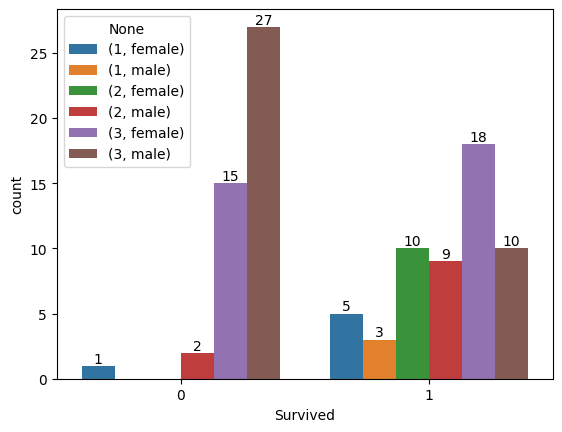

In [195]:
df_young = df[df["Age"] <= 16]
hue = df_young[["Pclass", "Sex"]].apply(lambda row: f"({row.Pclass}, {row.Sex})", axis=1)
hue_order = ["(1, female)", "(1, male)", "(2, female)", "(2, male)", "(3, female)", "(3, male)"]
# kid are generally survive more, half of the class 2 survior are kid under 12

ax = sns.countplot(df_young, x="Survived", hue=hue, hue_order=hue_order)

for container in ax.containers:
    ax.bar_label(container)

In [196]:
df[(df["Age"] >= 10) & (df["Age"]<=18)].groupby(["Pclass", "Sex"])["Survived"].agg(["count", "sum", "mean"])

count  sum      mean
Pclass Sex                         
1      female     10   10  1.000000
       male        3    2  0.666667
2      female      6    6  1.000000
       male        6    0  0.000000
3      female     22   11  0.500000
       male       30    3  0.100000

In [197]:
# Child feature is probly good

In [198]:
# child and dad 

<Axes: >

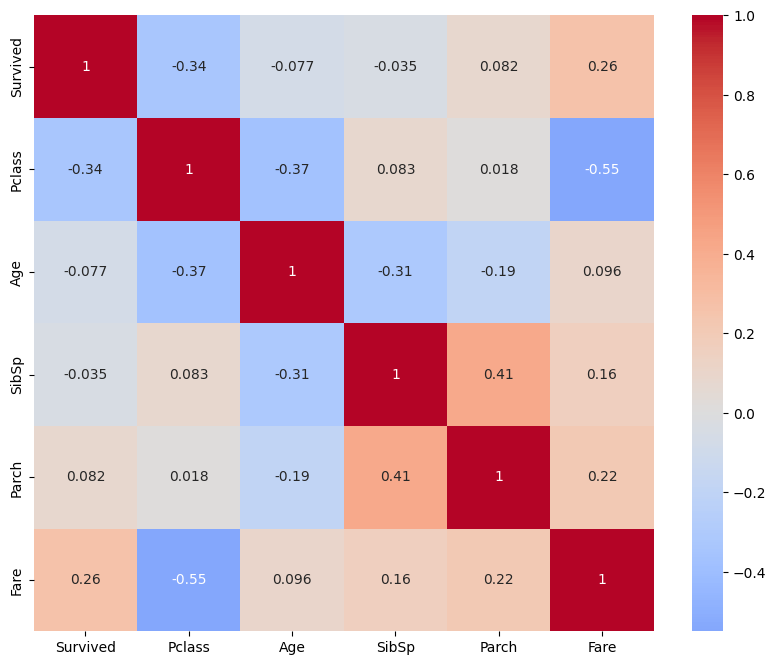

In [199]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

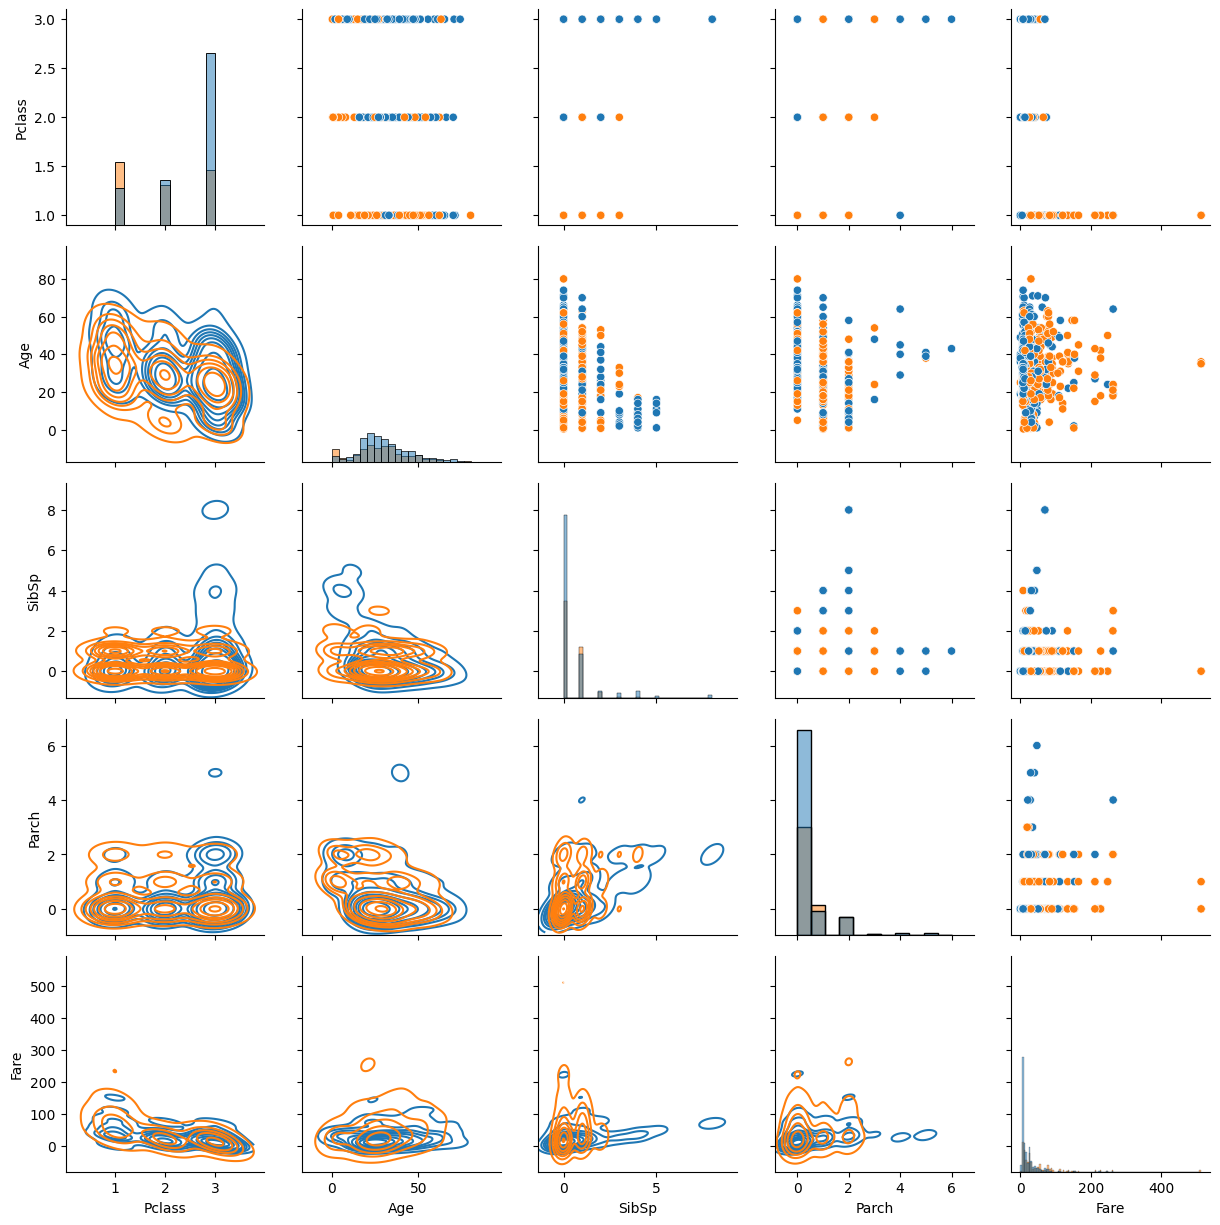

In [200]:
g = sns.PairGrid(df, hue="Survived")
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)

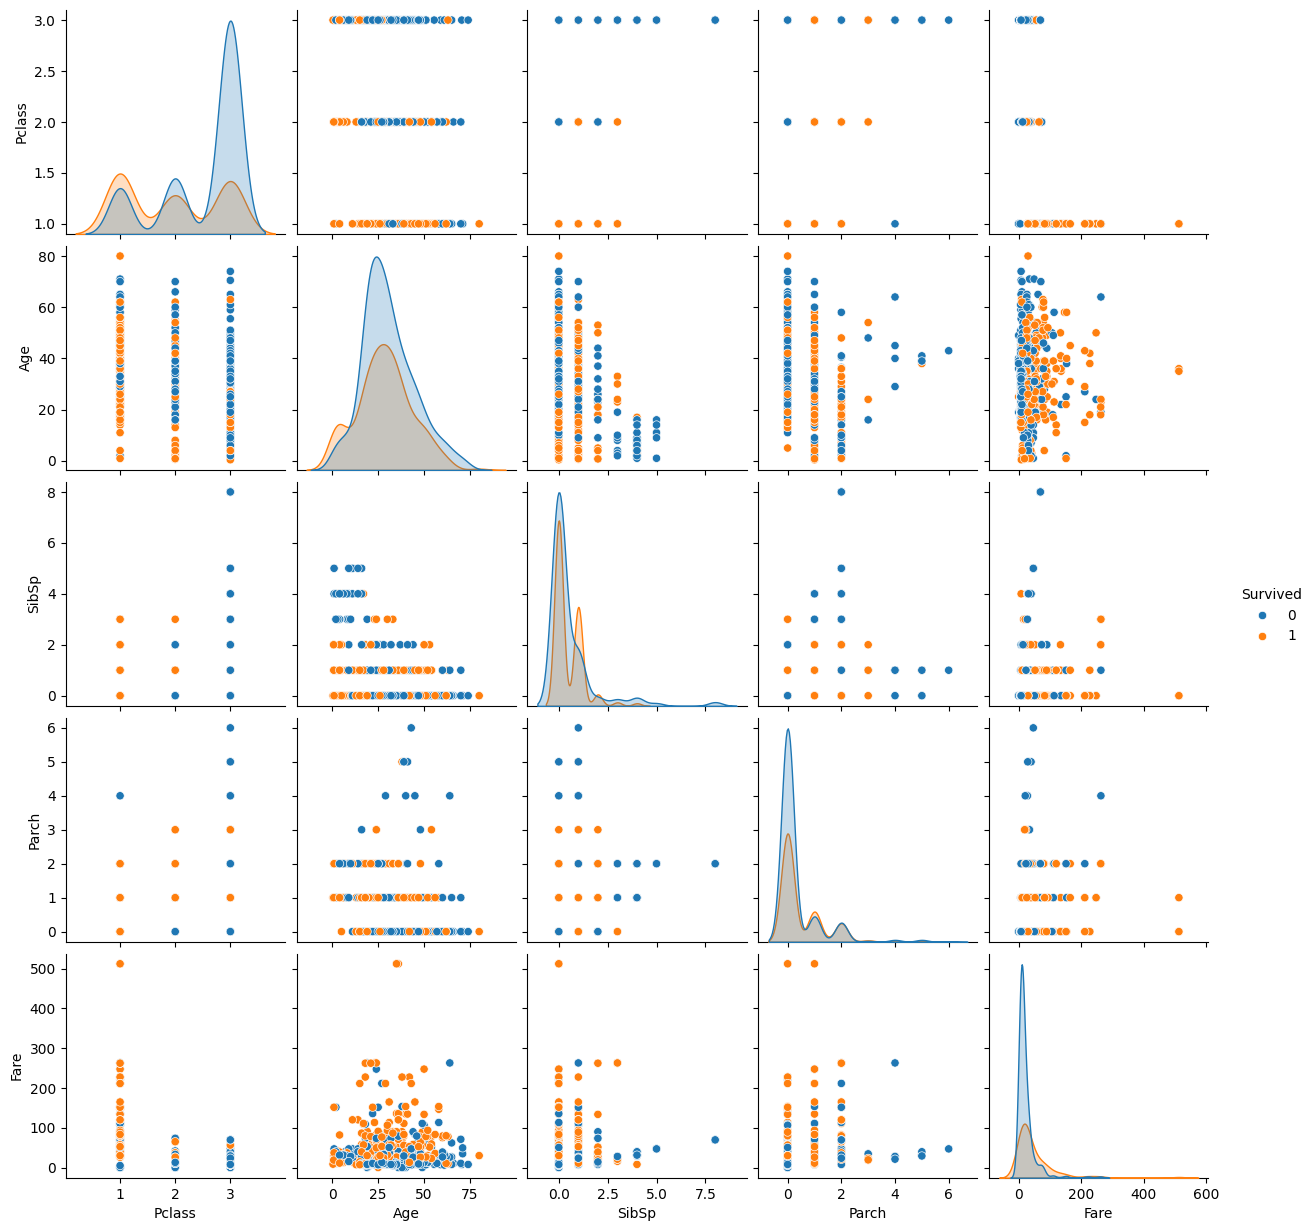

In [201]:
sns.pairplot(df, hue="Survived")

In [207]:
# 1. Log-transform Fare to handle skewness
# df["Fare_log"] = numpy.log1p(df["Fare"])

# 2. Create family size feature
# df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
# df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# 3. Create age bins
# df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=["Child", "Teen", "Adult", "Middle", "Senior"])

# 4. Extract title from Name (strong predictor)
# df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')

# 5. Cabin deck (first letter) - though many missing
# df["Deck"] = df["Cabin"].str[0]

# 6. Visualize new features
# sns.countplot(df, x="FamilySize", hue="Survived")


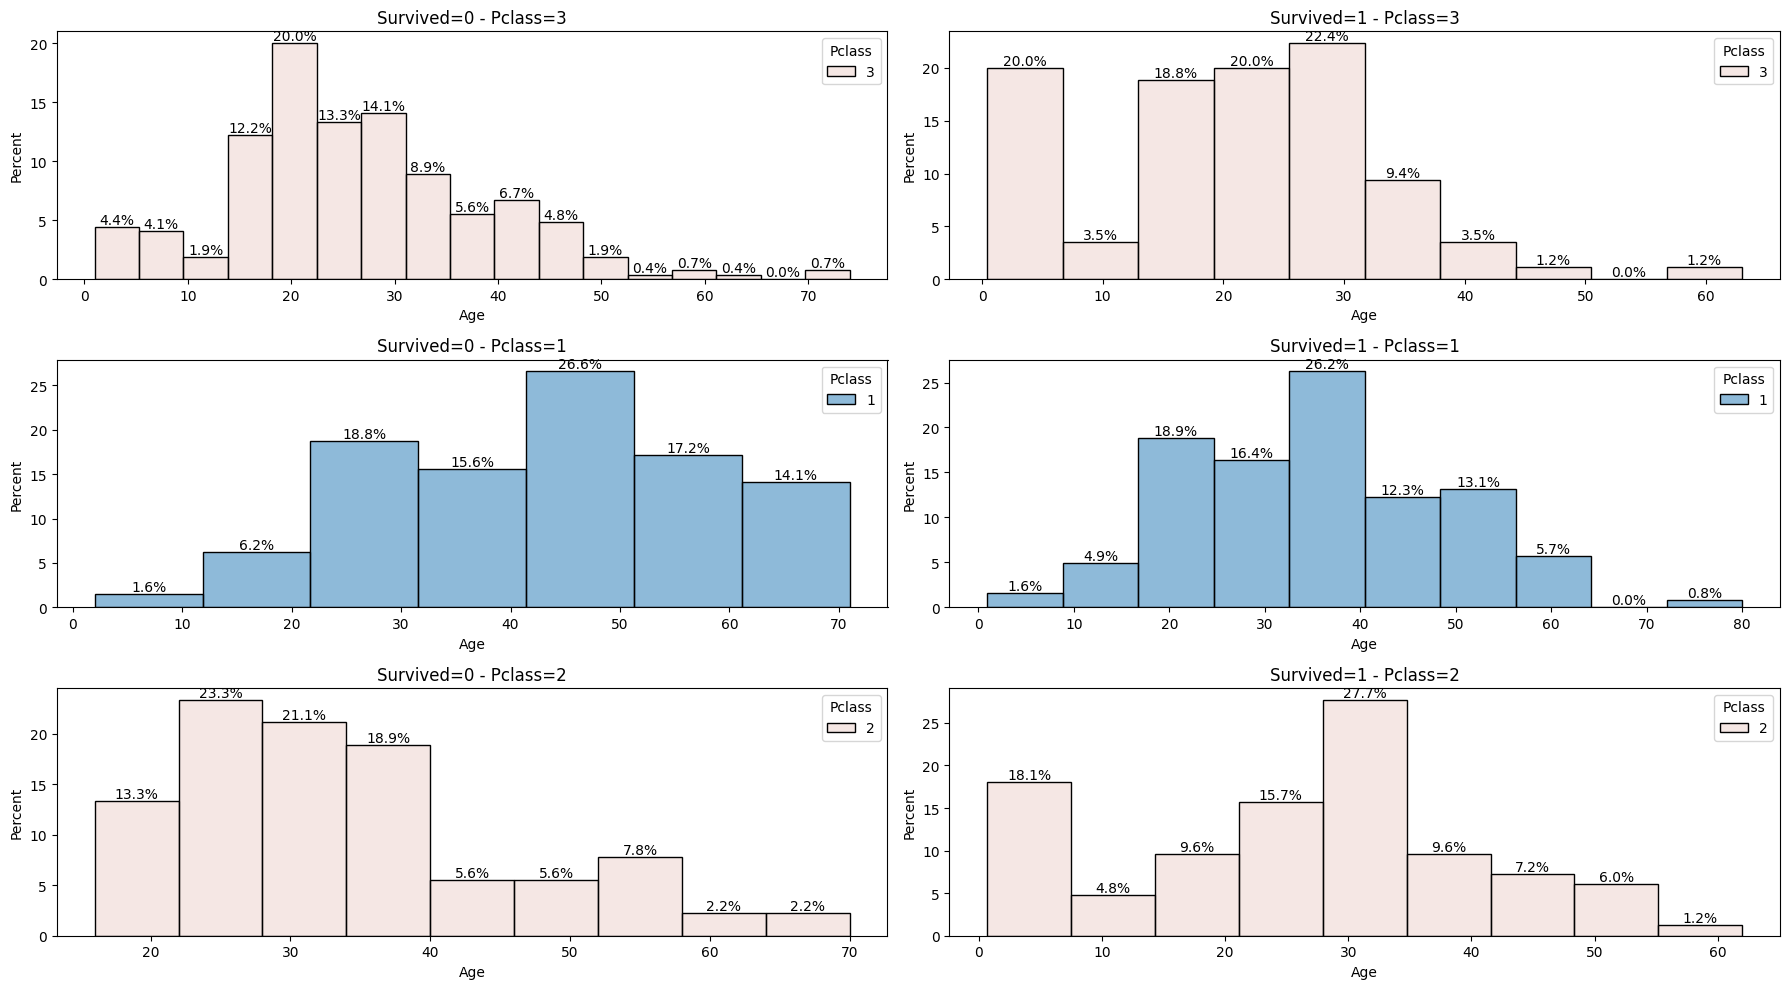

In [208]:
fig = plt.figure(figsize=(18, 10))  # lowercase 'figure' and use 'figsize='
grid = plt.GridSpec(3, 2, figure=fig)

survived_values = df["Survived"].unique()
pclasses_value = df["Pclass"].unique()


for row, survived in enumerate(survived_values):
    for col, pclass in enumerate(pclasses_value):
        ax = fig.add_subplot(grid[col, row])
        subset = df[(df["Survived"] == survived) &(df["Pclass"] == pclass)]
        sns.histplot(subset, x="Age", hue="Pclass", stat="percent", ax=ax)
        ax.set_title(f"Survived={survived} - Pclass={pclass}")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()  # call on fig, not plt
plt.show()

In [209]:
df[(df["Pclass"] == 1) & (df["Age"] < 10)]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
297,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
305,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
445,1,1,"Dodge, Master. Washington",male,4.00,0,2,33638,81.8583,A34,S


In [210]:
df["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [211]:
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')

In [212]:
df["Title"].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

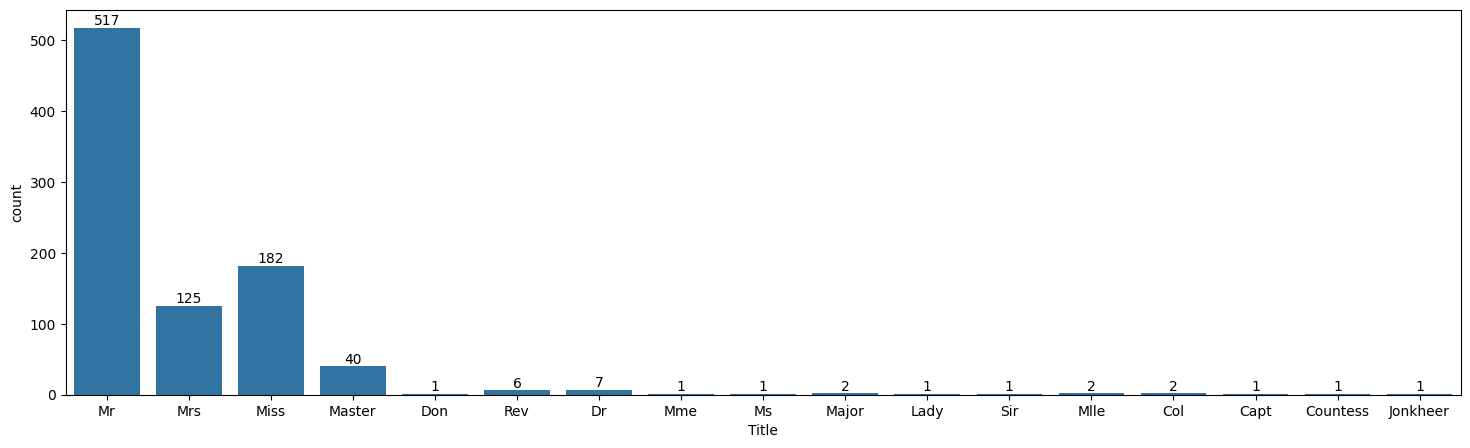

In [213]:
fig = plt.figure(figsize=[18, 5])

ax = sns.countplot(df, x="Title")
for container in ax.containers:
    ax.bar_label(container)

In [ ]:
# Keep only main titles, map others to "Rare"
main_titles = ['Mr', 'Mrs', 'Miss', 'Master']

df["Title"] = df["Title"].apply(lambda x: x if x in main_titles else "Rare")

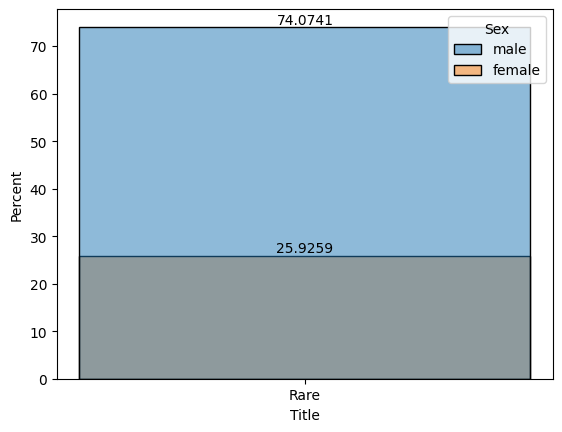

In [233]:

ax = sns.histplot(df[df["Title"] == "Rare"], x="Title", hue="Sex", stat="percent")
for container in ax.containers:
    ax.bar_label(container)

In [261]:
df[df["Title"] == "Rare"].groupby(["Sex"]).describe()

Survived                                           Pclass            \
          count  mean       std  min  25%  50%   75%  max  count      mean   
Sex                                                                          
female      7.0  1.00  0.000000  1.0  1.0  1.0  1.00  1.0    7.0  1.142857   
male       20.0  0.25  0.444262  0.0  0.0  0.0  0.25  1.0   20.0  1.400000   

        ... Parch       Fare                                                \
        ...   75%  max count       mean        std   min      25%      50%   
Sex     ...                                                                  
female  ...   0.0  0.0   7.0  50.447629  26.244481  13.0  32.7646  49.5042   
male    ...   0.0  1.0  20.0  35.143750  31.729447   0.0  13.0000  27.1354   

                        
           75%     max  
Sex                     
female  69.300   86.50  
male    36.525  133.65  

[2 rows x 48 columns]

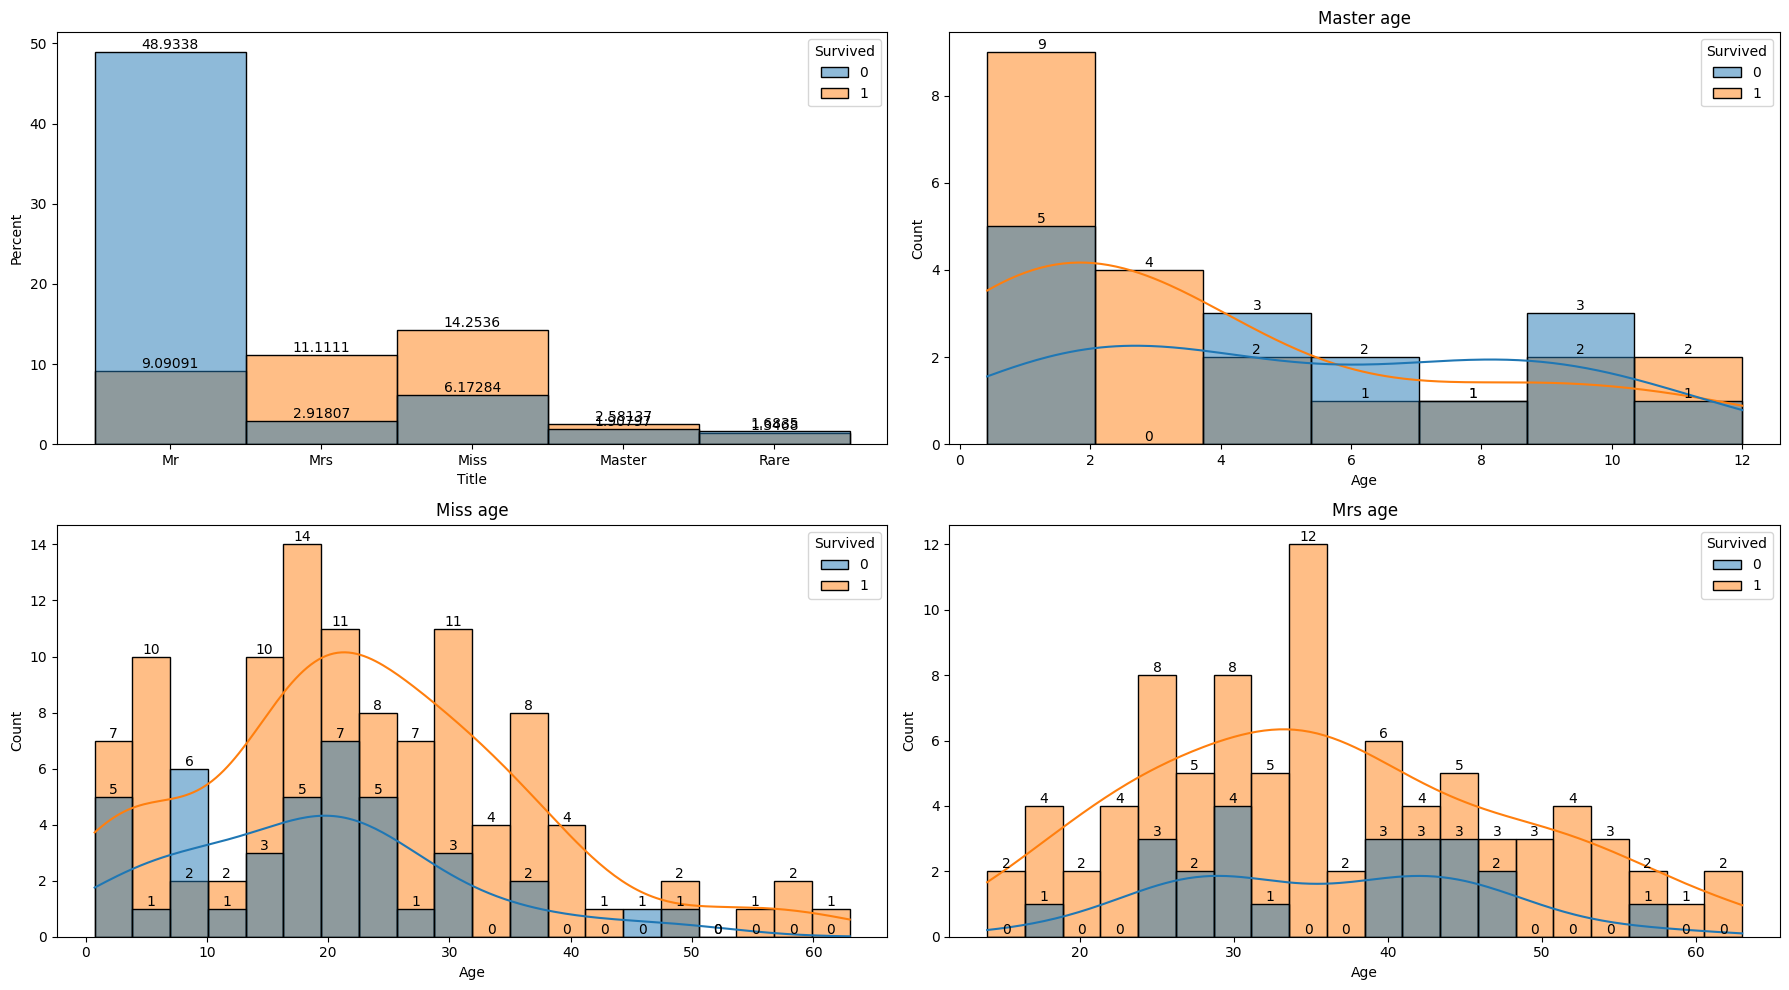

In [257]:
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

ax = sns.histplot(df, x="Title", hue="Survived", stat="percent", ax=ax1)
for container in ax.containers:
    ax.bar_label(container)
    
ax = sns.histplot(df[df["Title"] == "Master"], x="Age", hue="Survived", stat="count", ax=ax2, kde=True)
ax.set_title("Master age")
for container in ax.containers:
    ax.bar_label(container)
    
ax = sns.histplot(df[df["Title"] == "Miss"], x="Age", hue="Survived", stat="count", ax=ax3, kde=True, bins=20)
ax.set_title("Miss age")
for container in ax.containers:
    ax.bar_label(container)
    
ax = sns.histplot(df[df["Title"] == "Mrs"], x="Age", hue="Survived", stat="count", ax=ax4, kde=True, bins=20)

ax.set_title("Mrs age")
for container in ax.containers:
    ax.bar_label(container)
    
    
    
plt.tight_layout()
plt.show()